# Program-level cumulative fatigue damage — relative comparison

**Reference:** `13999` / `v58` · **Compare:** `COMPARE_PROGRAM_B` / `COMPARE_VERSION_B` (Step 11)

This notebook walks through cumulative program damage and **relative comparison** between two event sets or two program/version folders.

This notebook walks through the **two-layer damage model** used in durability analysis:

| Layer | Tool | Question it answers |
|-------|------|---------------------|
| **1 — Signal damage** | [py-fatigue](https://owi-lab.github.io/py_fatigue) rainflow + Palmgren–Miner | How much damage does **one pass** through this measured load history cause? |
| **2 — Schedule scaling** | autodam `.sch` file (`repeats`, `weight`, `*multiplier`) | How much does that event contribute over the **full program life**? |

References:
- RSP conversion: `notebooks/rsp_to_csv_v3.ipynb`
- Cycle counting & Miner damage: `notebooks/py_fatigue_cycle_counting.ipynb` and [py-fatigue damage example](https://owi-lab.github.io/py_fatigue/user/examples/07-damage.html)
- Schedule parsing & pattern matching: `notebooks/durability_schedule_extraction.ipynb`

---

## Design decisions (resolved for this notebook)

1. **Single-pass damage** uses Palmgren–Miner (`get_pm`) with DNV GL S–N curve C in air — same constants as `py_fatigue_cycle_counting.ipynb` and `server/services/fatigue_damage.py`.
2. **Program damage** = `D_single × repeats × weight × global_multiplier` (linear scaling; valid for linear PM).
3. **Channels:** the 12 Inspect Damage channels, resolved from CSV `#TITLES` using the same substring rules as `server/services/damage_channels.py`.
4. **Schedule matching:** longest substring containment on the RSP/CSV filename stem (same as `durability_schedule_extraction.ipynb`).
5. **Shared pipeline:** Steps 1–7 load function definitions from `relative_damage_calculation.ipynb` (same pattern as `load_rsp_converter()`). Only comparison logic lives in this notebook.
6. **Data source:** `DATA_SOURCE = "test"` (3 events, fast smoke test) or `"raw"` (~57 RSPs; only events with an existing CSV sidecar are used unless conversion succeeds).
7. **Relative metrics:** per channel, `ratio = D_B / D_A`, `pct_diff = 100 × (D_B − D_A) / D_A`, and **normalized ratio** = `(D_B / ΣD_B) / (D_A / ΣD_A)` (compare damage mix, not absolute scale).


## Step 0 — Configuration

Set program/version paths. The folder layout is `RAW_DATA/test/{program}/{version}/`.

In [16]:
from __future__ import annotations

import io
import json
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import py_fatigue as pf

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

PROGRAM = "13999"
VERSION = "v58"

# "test" = 3 events (fast); "raw" = full ~57-event slice (recommended for split comparison)
DATA_SOURCE = "raw"

# Step 11 cross-program comparison (set both to compare two program/version folders)
COMPARE_PROGRAM_B = "13999"
COMPARE_VERSION_B = "v58"

# Step 10 split comparison: random shuffle seed (None = different split each run)
SPLIT_RANDOM_SEED = 42



def find_repo_root() -> Path:
    start = Path.cwd().resolve()
    for d in [start, *start.parents]:
        if (d / "server" / "pyproject.toml").is_file():
            return d
    return start


REPO_ROOT = find_repo_root()

DATA_DIRS = {
    "test": REPO_ROOT / "RAW_DATA/test" / PROGRAM / VERSION,
    "raw": REPO_ROOT / "RAW_DATA/raw" / PROGRAM / f"{VERSION}_data_processing",
}
if DATA_SOURCE not in DATA_DIRS:
    raise ValueError(f"DATA_SOURCE must be one of {list(DATA_DIRS)}")
DATA_DIR = DATA_DIRS[DATA_SOURCE]

print(f"Repo root:   {REPO_ROOT}")
print(f"Data source: {DATA_SOURCE}")
print(f"Data dir:    {DATA_DIR}")
print(f"Exists:      {DATA_DIR.is_dir()}")

Repo root:   /data/home/tkodippili/Desktop/localTest_Analysis_DashboardV3/Dashboard
Data source: raw
Data dir:    /data/home/tkodippili/Desktop/localTest_Analysis_DashboardV3/Dashboard/RAW_DATA/raw/13999/v58_data_processing
Exists:      True


## Step 1 — Convert RSP files to tagged CSV

RSP binaries are converted to the tagged CSV format (`#HEADER`, `#TITLES`, `#UNITS`, `#DATA`) used elsewhere in this repo.

We **reuse** the conversion functions from `rsp_to_csv_v3.ipynb` so this notebook stays in sync with the canonical converter.

If an RSP already has a CSV sidecar, that file is reused. When conversion is needed but both installed parsers fail, the notebook **reuses a stale CSV if present** or **skips** the RSP with a warning — it does not abort the whole run.

In [17]:
def load_rsp_converter() -> None:
    """Exec the rsp_to_csv_v3 helper cell into the global namespace."""
    nb_path = REPO_ROOT / "notebooks/rsp_to_csv_v3.ipynb"
    nb = json.loads(nb_path.read_text(encoding="utf-8"))
    src = nb["cells"][1]["source"]
    if isinstance(src, list):
        src = "".join(src)
    demo_start = src.find("rsp_path = _find_repo_root()")
    exec(src[:demo_start], globals())


def convert_rsp_files(data_dir: Path) -> pd.DataFrame:
    """Convert or reuse CSV sidecars; skip RSPs that have no usable CSV."""
    load_rsp_converter()

    rsp_files = sorted(data_dir.glob("*.rsp"))
    if not rsp_files:
        raise FileNotFoundError(f"No .rsp files in {data_dir}")

    conversion_log: list[dict] = []
    for rsp_path in rsp_files:
        csv_path = rsp_path.with_suffix(".csv")
        csv_fresh = csv_path.exists() and csv_path.stat().st_mtime >= rsp_path.stat().st_mtime

        if csv_fresh:
            conversion_log.append(
                {"rsp": rsp_path.name, "csv": csv_path.name, "action": "reused existing csv"}
            )
            continue

        try:
            out, shape, channel_count, _ = rsp_to_tagged_csv(rsp_path, csv_path)
            conversion_log.append(
                {
                    "rsp": rsp_path.name,
                    "csv": out.name,
                    "rows": shape[0],
                    "channels": channel_count,
                    "action": "converted",
                }
            )
        except RuntimeError as exc:
            if csv_path.exists():
                conversion_log.append(
                    {
                        "rsp": rsp_path.name,
                        "csv": csv_path.name,
                        "action": "conversion failed — reused stale csv",
                        "error": str(exc).splitlines()[0],
                    }
                )
            else:
                conversion_log.append(
                    {
                        "rsp": rsp_path.name,
                        "csv": None,
                        "action": "skipped — no csv and conversion failed",
                        "error": str(exc).splitlines()[0],
                    }
                )

    log_df = pd.DataFrame(conversion_log)
    csv_available = len(list(data_dir.glob("*.csv")))
    skipped = log_df["action"].str.startswith("skipped", na=False).sum()
    print(f"CSV files available in {data_dir.name}: {csv_available}")
    if skipped:
        print(
            f"Warning: {skipped} RSP(s) skipped — install pyRPC3 or pre-convert CSVs to include them."
        )
    if csv_available == 0:
        raise RuntimeError(
            "No CSV files available after Step 1. "
            "Use DATA_SOURCE='test' or pre-convert RSP files in the raw folder."
        )
    return log_df


conversion_log_df = convert_rsp_files(DATA_DIR)
conversion_log_df

 Reading headers from:
	File: /data/home/tkodippili/Desktop/localTest_Analysis_DashboardV3/Dashboard/RAW_DATA/raw/13999/v58_data_processing/mfcs5_400_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr.rsp
 Reading headers from:
	File: /data/home/tkodippili/Desktop/localTest_Analysis_DashboardV3/Dashboard/RAW_DATA/raw/13999/v58_data_processing/mfwf5_400_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr.rsp
 Reading headers from:
	File: /data/home/tkodippili/Desktop/localTest_Analysis_DashboardV3/Dashboard/RAW_DATA/raw/13999/v58_data_processing/mfxf5f_400_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr_app.rsp
CSV files available in v58_data_processing: 54


,rsp,csv,action,error
0,mf4e1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,mf4e1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,reused existing csv,NaN
1,mf4e3_100_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,mf4e3_100_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,reused existing csv,NaN
2,mf4e3_400_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,mf4e3_400_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,reused existing csv,NaN
3,mf4f1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,mf4f1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,reused existing csv,NaN
4,mf4x1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,mf4x1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,reused existing csv,NaN
5,mf4x3_100_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,mf4x3_100_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,reused existing csv,NaN
6,mf4x3_400_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,mf4x3_400_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,reused existing csv,NaN
7,mfbm1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,mfbm1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,reused existing csv,NaN
8,mfbm3_100_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,mfbm3_100_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,reused existing csv,NaN
9,mfbm3_400_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,mfbm3_400_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,reused existing csv,NaN


## Step 2 — Load the durability schedule (`.sch`)

An autodam schedule lists event **glob patterns** with two scaling factors per entry:

- **`repeats`** — how many times that event runs over the program (e.g. 16, 6000).
- **`weight`** — ballast / mixing fraction (often 0.75 + 0.15 + 0.10 = 1.0 across ballast variants).

The header may also define `*multiplier` (global program scale, default 1.0).

These fields are **not** handled by py-fatigue — they scale damage **after** single-pass calculation.

In [18]:
def parse_autodam_schedule(path: Path) -> dict:
    path = path.expanduser().resolve()
    schedule = {
        "file": str(path),
        "schedule_id": None,
        "multiplier": 1.0,
        "entries": [],
    }
    entry_re = re.compile(r"^\*([^*]+)\*\s+(\d+)\s+([\d.]+)\s*$")
    id_re = re.compile(r"^\*id\s+(.+)$", re.IGNORECASE)
    mult_re = re.compile(r"^\*multiplier\s+([\d.]+)\s*$", re.IGNORECASE)

    for raw_line in path.read_text(errors="replace").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#"):
            continue
        if line.lower().startswith("*summary"):
            break
        if m := id_re.match(line):
            schedule["schedule_id"] = m.group(1).strip()
        elif m := mult_re.match(line):
            schedule["multiplier"] = float(m.group(1))
        elif m := entry_re.match(line):
            schedule["entries"].append(
                {
                    "pattern": m.group(1),
                    "repeats": int(m.group(2)),
                    "weight": float(m.group(3)),
                }
            )
    return schedule


sch_files = sorted(DATA_DIR.glob("*.sch"))
if not sch_files:
    raise FileNotFoundError(f"No .sch schedule in {DATA_DIR}")
if len(sch_files) > 1:
    print(f"Warning: multiple .sch files; using {sch_files[0].name}")

schedule = parse_autodam_schedule(sch_files[0])
schedule_df = pd.DataFrame(schedule["entries"])

print(f"Schedule file: {Path(schedule['file']).name}")
print(f"Schedule ID:   {schedule['schedule_id']}")
print(f"Multiplier:    {schedule['multiplier']}")
print(f"Entries:       {len(schedule_df)}")
schedule_df.head(8)

Schedule file: gmw17287_95per_bt1cc_iver.sch
Schedule ID:   gmw17287 2WD SUV VRLDA Major Durability 150,000 miles for 95th percentile
Multiplier:    1.0
Entries:       60


,pattern,repeats,weight
0,4e1,16,0.75
1,mf4e3_100,16,0.15
2,mf4e3_400,16,0.10
3,4f1,8,1.00
4,4x1,1200,0.75
5,mf4x3_100,1200,0.15
6,mf4x3_400,1200,0.10
7,bm1,4500,0.75


## Step 3 — Match each event file to a schedule row

Each CSV/RSP filename is matched to the **longest** schedule pattern contained in the filename stem.

Example: `mf4e3_100_bt1cc_...` matches pattern `mf4e3_100` (repeats=16, weight=0.15).

### Plot — schedule scale factors for matched events (Step 3a)

`repeats × weight × multiplier` is the factor applied to single-pass damage in Step 6.

,rsp_file_name,matched_pattern,repeats,weight,schedule_sequence,global_multiplier,schedule_scale
0,mf4e1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,4e1,16,0.75,1,1.0,12.00
1,mf4e3_100_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,mf4e3_100,16,0.15,2,1.0,2.40
2,mf4e3_400_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,mf4e3_400,16,0.10,3,1.0,1.60
3,mf4f1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,4f1,8,1.00,4,1.0,8.00
4,mf4x1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,4x1,1200,0.75,5,1.0,900.00
5,mf4x3_100_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,mf4x3_100,1200,0.15,6,1.0,180.00
6,mf4x3_400_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,mf4x3_400,1200,0.10,7,1.0,120.00
7,mfbm1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,bm1,4500,0.75,8,1.0,3375.00
8,mfbm3_100_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,mfbm3_100,4500,0.15,9,1.0,675.00
9,mfbm3_400_bt1cc_coil_2m24_lt27550r22_5dec22_lc...,mfbm3_400,4500,0.10,10,1.0,450.00


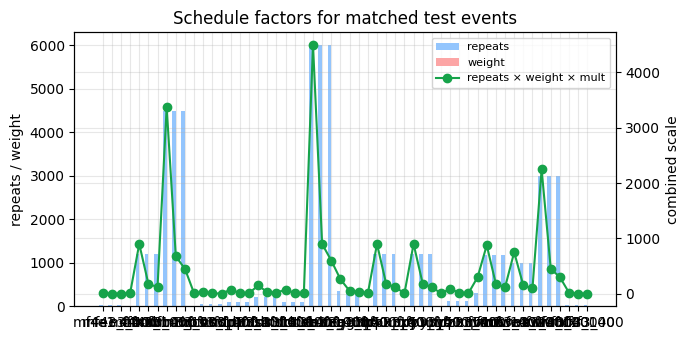

In [19]:
def match_schedule_pattern(stem: str, patterns: list[str]) -> str | None:
    matches = [p for p in patterns if p in stem]
    return max(matches, key=len) if matches else None


patterns = schedule_df["pattern"].tolist()
lookup = schedule_df.reset_index().rename(columns={"index": "schedule_sequence"})
lookup["schedule_sequence"] = lookup["schedule_sequence"] + 1

event_rows = []
for csv_path in sorted(DATA_DIR.glob("*.csv")):
    stem = csv_path.stem
    matched = match_schedule_pattern(stem, patterns)
    row = {"rsp_file_name": csv_path.name, "matched_pattern": matched}
    if matched:
        meta = lookup.loc[lookup["pattern"] == matched].iloc[0]
        row.update(
            {
                "repeats": int(meta["repeats"]),
                "weight": float(meta["weight"]),
                "schedule_sequence": int(meta["schedule_sequence"]),
            }
        )
    event_rows.append(row)

events_df = pd.DataFrame(event_rows)
events_df["global_multiplier"] = schedule["multiplier"]
events_df["schedule_scale"] = events_df["repeats"] * events_df["weight"] * events_df["global_multiplier"]

display(events_df)

fig, ax = plt.subplots(figsize=(7, 3.5))
labels = events_df["matched_pattern"].astype(str)
x = np.arange(len(labels))
ax.bar(x - 0.2, events_df["repeats"], width=0.4, label="repeats", color="#93c5fd")
ax.bar(x + 0.2, events_df["weight"], width=0.4, label="weight", color="#fca5a5")
ax2 = ax.twinx()
ax2.plot(x, events_df["schedule_scale"], "o-", color="#16a34a", label="repeats × weight × mult")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("repeats / weight")
ax2.set_ylabel("combined scale")
ax.set_title("Schedule factors for matched test events")
lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2, loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

## Step 4 — Single-pass signal damage (py-fatigue / Layer 1)

### What py-fatigue does

For each channel time series:

1. **Rainflow cycle counting** — `CycleCount.from_timeseries` extracts stress cycles (`count_cycle` = \(n_j\) per bin).
2. **S–N lookup** — each bin gets `cycles_to_failure` \(N_j\) from the material curve.
3. **Palmgren–Miner rule** ([docs](https://owi-lab.github.io/py_fatigue/user/examples/07-damage.html)):

\[
D_{\text{single}} = \sum_j \frac{n_j}{N_j}
\]

This is **damage for one execution** of the load history. Schedule `repeats` and `weight` are applied in the next step.

In [20]:
SN_CURVE = pf.SNCurve(
    [3, 5],
    intercept=[12.592, 16.320],
    norm="DNVGL-RP-C203/2016",
    environment="Air",
    curve="C",
)

MEAN_BIN_WIDTH = 100.0
RANGE_BIN_WIDTH = 100.0
MIN_POINTS = 3


def parse_tagged_csv(filepath: Path) -> tuple[pd.DataFrame, list[str]]:
    lines = filepath.read_text(encoding="utf-8", errors="replace").strip().split("\n")
    headers: list[str] = []
    data_start = 0
    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped == "#DATA":
            data_start = i + 1
            break
        if stripped == "#TITLES" and i + 1 < len(lines):
            headers = [h.strip() for h in lines[i + 1].split(",")]
    df = pd.read_csv(
        io.StringIO("\n".join(lines[data_start:])),
        header=None,
        dtype=float,
        on_bad_lines="warn",
    )
    if headers and len(headers) == df.shape[1]:
        df.columns = headers
    return df, headers


def single_pass_damage(values: np.ndarray) -> float:
    arr = np.asarray(values, dtype=float)
    finite = arr[np.isfinite(arr)]
    if finite.size < MIN_POINTS:
        return float("nan")
    time = np.arange(finite.size, dtype=float)
    cc = pf.CycleCount.from_timeseries(
        finite,
        time=time,
        mean_bin_width=MEAN_BIN_WIDTH,
        range_bin_width=RANGE_BIN_WIDTH,
    )
    return float(sum(pf.damage.stress_life.get_pm(cycle_count=cc, sn_curve=SN_CURVE)))


# Demo on first event, first matched BJ X channel
demo_csv = sorted(DATA_DIR.glob("*.csv"))[0]
demo_df, demo_headers = parse_tagged_csv(demo_csv)
title_cols = [c for c in demo_df.columns if isinstance(c, str) and c.strip()]
print(f"Demo file: {demo_csv.name}")
print(f"Measurement columns ({len(title_cols)}): {title_cols[:4]} ...")

Demo file: mf4e1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr_app.csv
Measurement columns (24): ['1 1 LR LBJ - Fx', '2 2 LR LBJ - Fy', '3 3 LR LBJ - Fz', '4 4 LR Spring to Lca - Fx'] ...


### Plot — measured load history (Step 4a)

Before cycle counting, inspect the raw channel signal. The [py-fatigue damage tutorial](https://owi-lab.github.io/py_fatigue/user/examples/07-damage.html) plots stress vs time the same way for a sinusoidal example; here we plot a slice of the measured RSP-derived channel.

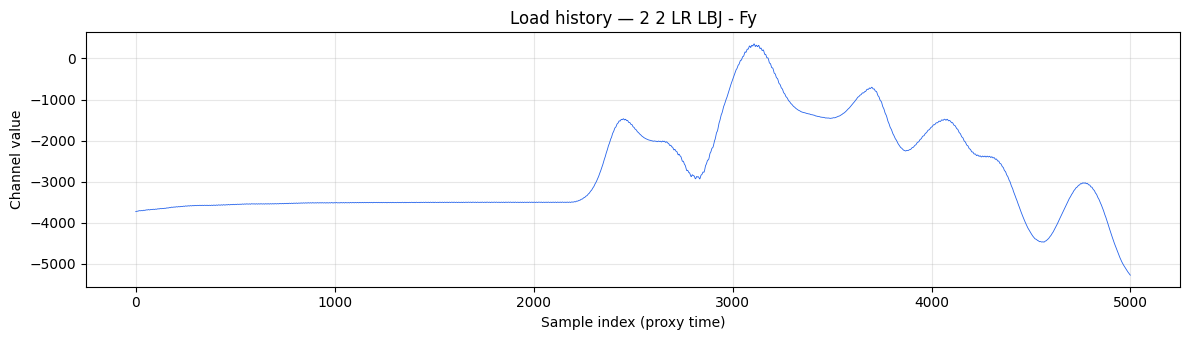

In [21]:
# Pick BJ Y column by title substring (full channel map comes in Step 5).
demo_col = next((c for c in title_cols if "LBJ" in str(c) and "Fy" in str(c)), None)
if demo_col:
    y = demo_df[demo_col].to_numpy(dtype=float)
    n_plot = min(5000, y.size)
    t = np.arange(n_plot, dtype=float)

    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(t, y[:n_plot], linewidth=0.6, color="#2563eb")
    ax.set_title(f"Load history — {demo_col}")
    ax.set_xlabel("Sample index (proxy time)")
    ax.set_ylabel("Channel value")
    fig.tight_layout()
    plt.show()
else:
    print("No BJ Fy column found for demo plot.")

## Step 5 — Resolve Inspect Damage channels

The dashboard uses 12 canonical damage channels (BJ / Shock / Bushing F&R × X/Y/Z).
We map CSV `#TITLES` to those keys using the same component/axis heuristics as `server/services/damage_channels.py`.

In [22]:
DAMAGE_CHANNEL_LABELS = {
    "bj_x_force": "BJ X Force",
    "bj_y_force": "BJ Y Force",
    "bj_z_force": "BJ Z Force",
    "shock_x_force": "Shock X Force",
    "shock_y_force": "Shock Y Force",
    "shock_z_force": "Shock Z Force",
    "bushing_f_x_momt": "Bushing F X Momt",
    "bushing_f_y_momt": "Bushing F Y Momt",
    "bushing_f_z_momt": "Bushing F Z Momt",
    "bushing_r_x_momt": "Bushing R X Momt",
    "bushing_r_y_momt": "Bushing R Y Momt",
    "bushing_r_z_momt": "Bushing R Z Momt",
}

DAMAGE_CHANNEL_PATTERNS: dict[str, tuple[tuple[str, ...], str]] = {
    "bj_x_force": (("balljoint", "balljnt", "lbj", "otrbj", "outerbj"), "x"),
    "bj_y_force": (("balljoint", "balljnt", "lbj", "otrbj", "outerbj"), "y"),
    "bj_z_force": (("balljoint", "balljnt", "lbj", "otrbj", "outerbj"), "z"),
    "shock_x_force": (("shock", "shk"), "x"),
    "shock_y_force": (("shock", "shk"), "y"),
    "shock_z_force": (("shock", "shk"), "z"),
    "bushing_f_x_momt": (("frontattachment", "frontbush", "frontbsh", "frontbushing", "lcabushingf", "front bush"), "x"),
    "bushing_f_y_momt": (("frontattachment", "frontbush", "frontbsh", "frontbushing", "lcabushingf", "front bush"), "y"),
    "bushing_f_z_momt": (("frontattachment", "frontbush", "frontbsh", "frontbushing", "lcabushingf", "front bush"), "z"),
    "bushing_r_x_momt": (("rearattachment", "rearbush", "rearbsh", "rearbushing", "lcabushingr", "rear bush"), "x"),
    "bushing_r_y_momt": (("rearattachment", "rearbush", "rearbsh", "rearbushing", "lcabushingr", "rear bush"), "y"),
    "bushing_r_z_momt": (("rearattachment", "rearbush", "rearbsh", "rearbushing", "lcabushingr", "rear bush"), "z"),
}


def _normalized(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", value.lower())


def _tokens(value: str) -> set[str]:
    return {token for token in re.split(r"[^a-z0-9]+", value.lower()) if token}


def resolve_damage_columns(title_columns: list[str]) -> dict[str, str]:
    """Return {channel_key: csv_column_title} for uniquely matched channels."""
    resolved: dict[str, str] = {}
    for key, (component_patterns, axis) in DAMAGE_CHANNEL_PATTERNS.items():
        matches = []
        for col in title_columns:
            col_text = str(col)
            norm = _normalized(col_text)
            if not any(p.replace(" ", "") in norm or p in norm for p in component_patterns):
                continue
            toks = _tokens(col_text)
            if axis in toks or f"f{axis}" in toks or f"-{axis}" in col_text.lower():
                matches.append(col_text)
        if len(matches) == 1:
            resolved[key] = matches[0]
    return resolved


demo_map = resolve_damage_columns(title_cols)
pd.DataFrame([{"channel_key": k, "label": DAMAGE_CHANNEL_LABELS[k], "csv_column": v} for k, v in demo_map.items()])

,channel_key,label,csv_column
0,bj_x_force,BJ X Force,1 1 LR LBJ - Fx
1,bj_y_force,BJ Y Force,2 2 LR LBJ - Fy
2,bj_z_force,BJ Z Force,3 3 LR LBJ - Fz
3,shock_x_force,Shock X Force,7 10 LR SHK LWR MNT - Fx
4,shock_y_force,Shock Y Force,8 11 LR SHK LWR MNT - Fy
5,shock_z_force,Shock Z Force,9 12 LR SHK LWR MNT - Fz
6,bushing_f_x_momt,Bushing F X Momt,10 13 LR LCA FRONT BUSH - Fx
7,bushing_f_y_momt,Bushing F Y Momt,11 14 LR LCA FRONT BUSH - Fy
8,bushing_f_z_momt,Bushing F Z Momt,12 15 LR LCA FRONT BUSH - Fz
9,bushing_r_x_momt,Bushing R X Momt,13 16 LR LCA REAR BUSH - Fx


### Plot — rainflow cycle-count histogram (Step 5b)

After resolving channels, `CycleCount.plot_histogram()` visualises the rainflow matrix (mean stress vs stress range). See [CycleCount definition](https://owi-lab.github.io/py_fatigue/user/examples/04-cyclecount-definition.html) and [CycleCount plotting in the user guide](https://owi-lab.github.io/py_fatigue/user/examples/04-cyclecount-definition.html). Marker size/colour encodes cycle count \(n_j\) per bin — the inputs to Palmgren–Miner ([damage example](https://owi-lab.github.io/py_fatigue/user/examples/07-damage.html)).

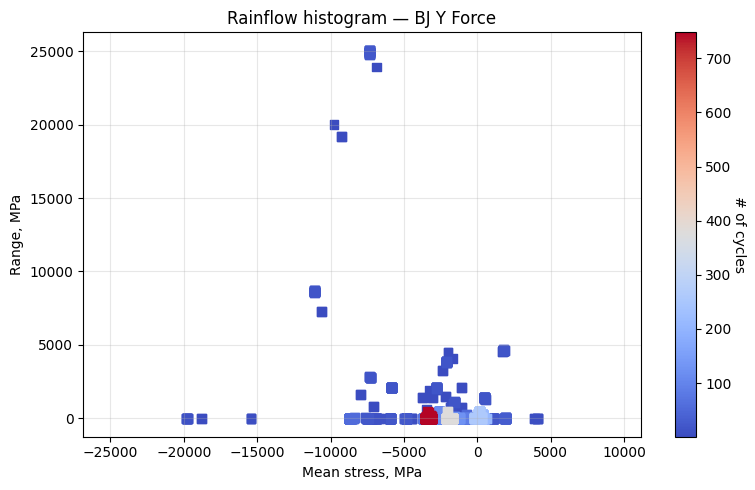

CC_BJ Y Force (12 Jun 2026, 15:18 - 


In [23]:
demo_channel_key = "bj_y_force"
demo_col = demo_map.get(demo_channel_key)
if demo_col:
    demo_values = demo_df[demo_col].to_numpy(dtype=float)
    demo_finite = demo_values[np.isfinite(demo_values)]
    demo_cc = pf.CycleCount.from_timeseries(
        demo_finite,
        time=np.arange(demo_finite.size, dtype=float),
        mean_bin_width=MEAN_BIN_WIDTH,
        range_bin_width=RANGE_BIN_WIDTH,
        name=DAMAGE_CHANNEL_LABELS[demo_channel_key],
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    demo_cc.plot_histogram(
        fig=fig,
        ax=ax,
        plot_type="mean-range",
        marker="s",
        s=40,
        cmap=mpl.colormaps["coolwarm"],
    )
    ax.set_title(f"Rainflow histogram — {DAMAGE_CHANNEL_LABELS[demo_channel_key]}")
    fig.tight_layout()
    plt.show()

    print(demo_cc)  # summary stats from CycleCount
else:
    print("Skip histogram: demo channel not resolved.")

## Step 6 — Combine layers: program damage per event × channel

\[
D_{\text{program, event, channel}} = D_{\text{single}} \times \text{repeats} \times \text{weight} \times \text{global\_multiplier}
\]

Special cases:
- `repeats = 0` or `weight = 0` → zero scheduled contribution.
- Unmatched schedule pattern → row flagged; no program scaling applied.

In [24]:
def schedule_scale(repeats: int | float, weight: float, multiplier: float) -> float:
    return float(repeats) * float(weight) * float(multiplier)


def compute_program_damage_detail(
    events: pd.DataFrame,
    data_dir: Path,
    program: str,
    version: str,
) -> pd.DataFrame:
    """Layer 1 + Layer 2 damage for each event × channel in the supplied event subset."""
    detail_rows: list[dict] = []

    for _, event in events.iterrows():
        csv_path = data_dir / event["rsp_file_name"]
        df, _headers = parse_tagged_csv(csv_path)
        title_cols = [c for c in df.columns if isinstance(c, str) and str(c).strip()]
        channel_map = resolve_damage_columns(title_cols)

        matched = pd.notna(event.get("matched_pattern")) and event.get("matched_pattern")
        scale = (
            schedule_scale(event["repeats"], event["weight"], event["global_multiplier"])
            if matched
            else float("nan")
        )

        for channel_key, col_name in channel_map.items():
            values = df[col_name].to_numpy()
            d_single = single_pass_damage(values)
            d_program = d_single * scale if matched and np.isfinite(d_single) else float("nan")
            detail_rows.append(
                {
                    "program": program,
                    "version": version,
                    "rsp_file_name": event["rsp_file_name"],
                    "matched_pattern": event.get("matched_pattern"),
                    "repeats": event.get("repeats"),
                    "weight": event.get("weight"),
                    "schedule_scale": scale,
                    "channel_key": channel_key,
                    "channel_label": DAMAGE_CHANNEL_LABELS[channel_key],
                    "csv_column": col_name,
                    "d_single": d_single,
                    "d_program": d_program,
                }
            )

    return pd.DataFrame(detail_rows)


def compute_cumulative_by_channel(detail_df: pd.DataFrame) -> pd.DataFrame:
    cumulative = (
        detail_df.groupby(["channel_key", "channel_label"], as_index=False)
        .agg(
            cumulative_d_program=("d_program", "sum"),
            events_contributing=("d_program", lambda s: int(np.isfinite(s).sum())),
            max_d_single=("d_single", "max"),
        )
        .sort_values("cumulative_d_program", ascending=False)
    )
    total = cumulative["cumulative_d_program"].sum()
    cumulative["pct_of_total"] = 100.0 * cumulative["cumulative_d_program"] / total
    return cumulative


detail_df = compute_program_damage_detail(events_df, DATA_DIR, PROGRAM, VERSION)
detail_df.sort_values(["rsp_file_name", "channel_key"]).head(12)

,program,version,rsp_file_name,matched_pattern,repeats,weight,schedule_scale,channel_key,channel_label,csv_column,d_single,d_program
0,13999,v58,mf4e1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,4e1,16,0.75,12.0,bj_x_force,BJ X Force,1 1 LR LBJ - Fx,0.184671,2.216054
1,13999,v58,mf4e1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,4e1,16,0.75,12.0,bj_y_force,BJ Y Force,2 2 LR LBJ - Fy,78.867726,946.412711
2,13999,v58,mf4e1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,4e1,16,0.75,12.0,bj_z_force,BJ Z Force,3 3 LR LBJ - Fz,65.127855,781.534256
6,13999,v58,mf4e1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,4e1,16,0.75,12.0,bushing_f_x_momt,Bushing F X Momt,10 13 LR LCA FRONT BUSH - Fx,0.021494,0.257927
7,13999,v58,mf4e1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,4e1,16,0.75,12.0,bushing_f_y_momt,Bushing F Y Momt,11 14 LR LCA FRONT BUSH - Fy,14.659979,175.919751
8,13999,v58,mf4e1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,4e1,16,0.75,12.0,bushing_f_z_momt,Bushing F Z Momt,12 15 LR LCA FRONT BUSH - Fz,0.249292,2.991509
9,13999,v58,mf4e1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,4e1,16,0.75,12.0,bushing_r_x_momt,Bushing R X Momt,13 16 LR LCA REAR BUSH - Fx,0.032920,0.395034
10,13999,v58,mf4e1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,4e1,16,0.75,12.0,bushing_r_y_momt,Bushing R Y Momt,14 17 LR LCA REAR BUSH - Fy,3.230084,38.761010
11,13999,v58,mf4e1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,4e1,16,0.75,12.0,bushing_r_z_momt,Bushing R Z Momt,15 18 LR LCA REAR BUSH - Fz,7.670726,92.048711
3,13999,v58,mf4e1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr...,4e1,16,0.75,12.0,shock_x_force,Shock X Force,7 10 LR SHK LWR MNT - Fx,0.000029,0.000348


## Step 7 — Cumulative program damage per channel

Sum `d_program` across all events in this folder for each channel.

> **Note:** With only the 3-file test slice, these totals cover the **4e1 ballast family only**. A production run would iterate all RSP files for program 13999 / version v58.

### Plot — cumulative damage by channel (Step 7a)

Bar chart of partial program-level damage summed across the test events. Values are dimensionless Miner damage \(D\); compare channels and events relatively, not to an absolute failure threshold, unless calibrated for your S–N curve and units.

Program 13999 / v58 — partial cumulative damage (test folder only)
Schedule: gmw17287 2WD SUV VRLDA Major Durability 150,000 miles for 95th percentile
Global multiplier: 1.0
Events processed: 54
Sum of channel cumulative damage: 679655.056158



,channel_key,channel_label,cumulative_d_program,events_contributing,max_d_single,pct_of_total
2,bj_z_force,BJ Z Force,392935.304283,54,134.750154,57.813931
1,bj_y_force,BJ Y Force,247785.822007,54,88.113755,36.457585
0,bj_x_force,BJ X Force,23201.819963,54,75.457638,3.413764
4,bushing_f_y_momt,Bushing F Y Momt,4142.433304,36,36.863397,0.609491
7,bushing_r_y_momt,Bushing R Y Momt,3382.547784,36,33.692777,0.497686
8,bushing_r_z_momt,Bushing R Z Momt,3248.094260,36,8.330889,0.477903
11,shock_z_force,Shock Z Force,3021.881362,36,42.058782,0.444620
6,bushing_r_x_momt,Bushing R X Momt,1166.998445,36,15.077204,0.171705
3,bushing_f_x_momt,Bushing F X Momt,619.815212,36,7.412293,0.091196
5,bushing_f_z_momt,Bushing F Z Momt,133.662424,36,0.772103,0.019666


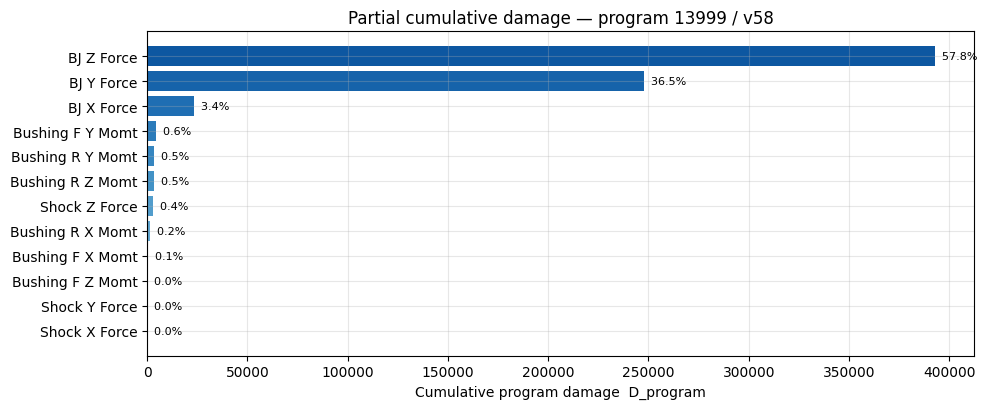

In [25]:
cumulative_df = compute_cumulative_by_channel(detail_df)
total_program_damage = cumulative_df["cumulative_d_program"].sum()

print(f"Program {PROGRAM} / {VERSION} — partial cumulative damage (test folder only)")
print(f"Schedule: {schedule['schedule_id']}")
print(f"Global multiplier: {schedule['multiplier']}")
print(f"Events processed: {events_df['rsp_file_name'].nunique()}")
print(f"Sum of channel cumulative damage: {total_program_damage:.6f}\n")

display(cumulative_df)

# Bar chart — top channels by cumulative program damage
plot_df = cumulative_df.sort_values("cumulative_d_program", ascending=True)
fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))
colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(plot_df)))
ax.barh(plot_df["channel_label"], plot_df["cumulative_d_program"], color=colors)
ax.set_xlabel("Cumulative program damage  D_program")
ax.set_title(f"Partial cumulative damage — program {PROGRAM} / {VERSION}")
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row["cumulative_d_program"], i, f"  {row['pct_of_total']:.1f}%", va="center", fontsize=8)
fig.tight_layout()
plt.show()

## Step 8 — Event contribution matrix (% of channel total)

Useful for comparing which ballast variant (0.75 / 0.15 / 0.10 weight) drives each channel.

### Plot — stacked contribution by ballast variant (Step 8a)

Each bar shows how the three test events split cumulative damage for one channel. Labels use the matched schedule pattern (e.g. `4e1`, `mf4e3_100`, `mf4e3_400`).

Program damage by event (absolute)


channel_key,bj_x_force,bj_y_force,bj_z_force,bushing_f_x_momt,bushing_f_y_momt,bushing_f_z_momt,bushing_r_x_momt,bushing_r_y_momt,bushing_r_z_momt,shock_x_force,shock_y_force,shock_z_force
rsp_file_name,,,,,,,,,,,,
mf4e1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr_app.csv,2.2161,946.4127,781.5343,0.2579,175.9198,2.9915,0.3950,38.7610,92.0487,0.0003,1.3302,211.0644
mf4e3_100_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr_app.csv,1.1782,199.0382,219.4719,0.1372,36.2803,1.5634,0.2270,10.4710,19.5104,0.0002,0.3943,85.2642
mf4e3_400_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr_app.csv,0.9441,116.4567,161.3815,0.1124,22.3012,1.2354,0.1799,8.5171,13.3294,0.0002,0.2335,67.2941
mf4f1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr.csv,5.2930,72.1450,32.5585,1.8373,12.6033,0.1052,0.8640,12.1873,6.3153,0.0001,0.0526,5.2917
mf4x1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr_app.csv,10.2160,2448.8760,3791.3552,1.1120,398.9374,11.5342,1.7664,85.2164,1815.3568,0.0000,1.2231,132.7203
mf4x3_100_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr_app.csv,4.5097,777.4386,1110.8260,0.4639,119.9275,1.7118,0.8538,25.0592,428.2600,0.0000,0.1242,58.1163
mf4x3_400_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr_app.csv,2.6858,458.3989,669.6599,0.2735,70.3548,1.3702,0.5091,14.8526,286.1297,0.0000,0.1141,27.2549
mfbm1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr.csv,604.0360,15.6120,31.3569,20.3932,305.0554,0.4160,207.8384,272.4673,20.3011,0.0000,0.0295,4.6513
mfbm3_100_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr.csv,197.4659,2.5310,11.8303,5.5512,102.6579,0.0797,77.0122,85.5521,6.9021,0.0000,0.0026,1.1571


Share of each channel total (%)


channel_key,bj_x_force,bj_y_force,bj_z_force,bushing_f_x_momt,bushing_f_y_momt,bushing_f_z_momt,bushing_r_x_momt,bushing_r_y_momt,bushing_r_z_momt,shock_x_force,shock_y_force,shock_z_force
rsp_file_name,,,,,,,,,,,,
mf4e1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr_app.csv,0.0,0.4,0.2,0.0,4.2,2.2,0.0,1.1,2.8,0.9,8.0,7.0
mf4e3_100_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr_app.csv,0.0,0.1,0.1,0.0,0.9,1.2,0.0,0.3,0.6,0.5,2.4,2.8
mf4e3_400_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr_app.csv,0.0,0.0,0.0,0.0,0.5,0.9,0.0,0.3,0.4,0.5,1.4,2.2
mf4f1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr.csv,0.0,0.0,0.0,0.3,0.3,0.1,0.1,0.4,0.2,0.3,0.3,0.2
mf4x1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr_app.csv,0.0,1.0,1.0,0.2,9.6,8.6,0.2,2.5,55.9,0.0,7.4,4.4
mf4x3_100_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr_app.csv,0.0,0.3,0.3,0.1,2.9,1.3,0.1,0.7,13.2,0.0,0.7,1.9
mf4x3_400_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr_app.csv,0.0,0.2,0.2,0.0,1.7,1.0,0.0,0.4,8.8,0.0,0.7,0.9
mfbm1_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr.csv,2.6,0.0,0.0,3.3,7.4,0.3,17.8,8.1,0.6,0.0,0.2,0.2
mfbm3_100_bt1cc_coil_2m24_lt27550r22_5dec22_lca_lr.csv,0.9,0.0,0.0,0.9,2.5,0.1,6.6,2.5,0.2,0.0,0.0,0.0


Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.


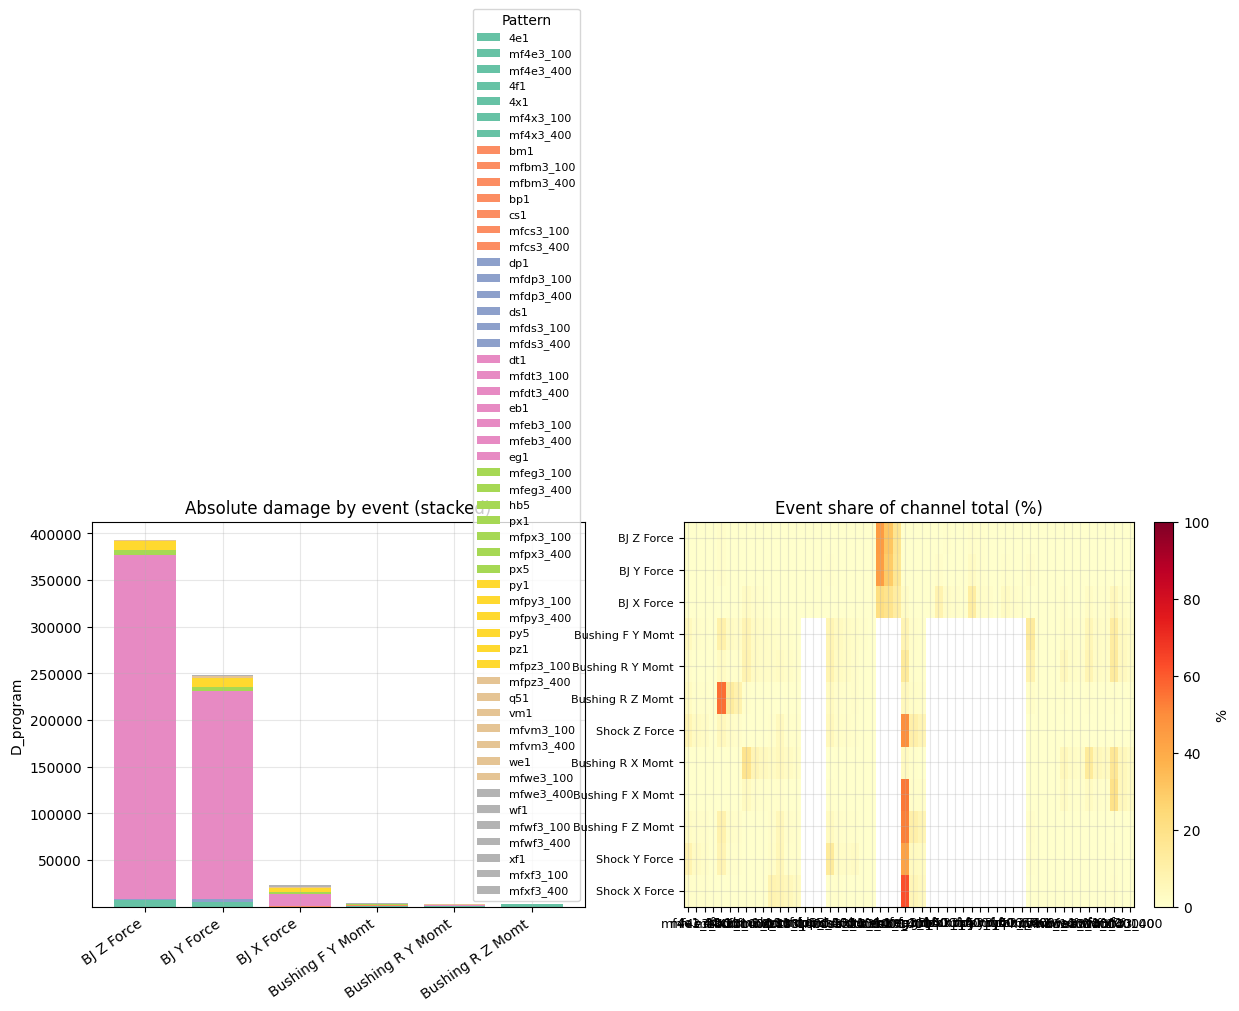

In [26]:
pivot = detail_df.pivot_table(
    index="rsp_file_name",
    columns="channel_key",
    values="d_program",
    aggfunc="first",
)

pct_pivot = pivot.div(pivot.sum(axis=0), axis=1) * 100.0
print("Program damage by event (absolute)")
display(pivot.round(4))
print("Share of each channel total (%)")
display(pct_pivot.round(1))

# Stacked bar chart — top 6 channels by total program damage
top_channels = (
    cumulative_df.sort_values("cumulative_d_program", ascending=False)
    .head(6)["channel_key"]
    .tolist()
)
event_labels = [
    detail_df.loc[detail_df["rsp_file_name"] == idx, "matched_pattern"].iloc[0]
    for idx in pivot.index
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute stacked bars
bottom = np.zeros(len(top_channels))
x = np.arange(len(top_channels))
palette = plt.cm.Set2(np.linspace(0, 1, len(pivot.index)))
for i, (event_name, pattern_label) in enumerate(zip(pivot.index, event_labels)):
    vals = pivot.loc[event_name, top_channels].fillna(0).to_numpy()
    axes[0].bar(x, vals, bottom=bottom, label=f"{pattern_label}", color=palette[i])
    bottom += vals
axes[0].set_xticks(x)
axes[0].set_xticklabels([DAMAGE_CHANNEL_LABELS[k] for k in top_channels], rotation=35, ha="right")
axes[0].set_ylabel("D_program")
axes[0].set_title("Absolute damage by event (stacked)")
axes[0].legend(title="Pattern", fontsize=8)

# Percent share heatmap for all resolved channels
hm = pct_pivot.T.loc[
    [k for k in cumulative_df["channel_key"] if k in pct_pivot.columns]
]
im = axes[1].imshow(hm.to_numpy(), aspect="auto", cmap="YlOrRd", vmin=0, vmax=100)
axes[1].set_yticks(range(len(hm.index)))
axes[1].set_yticklabels([DAMAGE_CHANNEL_LABELS[k] for k in hm.index], fontsize=8)
axes[1].set_xticks(range(len(hm.columns)))
axes[1].set_xticklabels(
    [detail_df.loc[detail_df["rsp_file_name"] == c, "matched_pattern"].iloc[0] for c in hm.columns],
    fontsize=9,
)
axes[1].set_title("Event share of channel total (%)")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="%")
fig.tight_layout()
plt.show()

## Step 10 — Split-event comparison (prototype for relative damage)

Randomly shuffle the matched event set, then split into **two halves with equal event count** (if the count is odd, one randomly placed event is dropped after the shuffle).

For each half we run the full program-level cumulative damage pipeline (Steps 6–7), then compare per channel:

| Metric | Formula | Use |
|--------|---------|-----|
| **Ratio** | \(D_B / D_A\) | Relative scale — same logic as comparing two program/versions |
| **% difference** | \(100 \times (D_B - D_A) / D_A\) | Signed deviation from reference set |

This validates the comparison machinery on one program before applying it across two program/version folders in Step 11.



Split random seed: 42
Set A patterns: ['mfds3_400', 'mfwf3_100', 'wf1', 'mfcs3_100', 'mfvm3_400', 'mf4x3_100', 'ds1', 'mfxf3_100', '4f1', 'mfpx3_400', 'mfcs3_400', 'mfbm3_100', 'eg1', 'mf4x3_400', 'py1', '4x1', 'py5', 'mfeb3_100', 'we1', 'px5', 'mfwf3_400', 'mfdp3_100', 'mfbm3_400', 'mfdp3_400', 'px1', 'mfpy3_400', 'mfeb3_400']
Set B patterns: ['cs1', '4e1', 'mfwe3_400', 'mfeg3_100', 'mfpx3_100', 'mfpz3_400', 'hb5', 'mfwe3_100', 'mf4e3_100', 'mfdt3_100', 'mf4e3_400', 'q51', 'mfpz3_100', 'mfpy3_100', 'eb1', 'mfvm3_100', 'bp1', 'mfdt3_400', 'mfds3_100', 'mfxf3_400', 'dt1', 'bm1', 'vm1', 'dp1', 'mfeg3_400', 'xf1', 'pz1']


,channel_key,channel_label,cumulative_d_program_a,events_contributing_a,max_d_single_a,pct_of_total_a,cumulative_d_program_b,events_contributing_b,max_d_single_b,pct_of_total_b,ratio_b_over_a,pct_diff,normalized_ratio_b_over_a,low_reference_a,label_a,label_b
4,bushing_f_y_momt,Bushing F Y Momt,2023.9989,17,36.8634,0.5657,2118.4344,19,34.5889,0.6581,1.0467,4.6658,1.1632,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
6,bushing_r_x_momt,Bushing R X Momt,593.4792,17,15.0772,0.1659,573.5192,19,13.0325,0.1782,0.9664,-3.3632,1.0740,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
1,bj_y_force,BJ Y Force,128537.8362,27,80.6125,35.9290,119247.9858,27,88.1138,37.0451,0.9277,-7.2273,1.0311,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
2,bj_z_force,BJ Z Force,205123.7174,27,134.7502,57.3363,187811.5869,27,134.5334,58.3448,0.9156,-8.4398,1.0176,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
7,bushing_r_y_momt,Bushing R Y Momt,1800.5052,17,33.6928,0.5033,1582.0426,19,29.8700,0.4915,0.8787,-12.1334,0.9765,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
0,bj_x_force,BJ X Force,14355.4105,27,75.4576,4.0126,8846.4095,27,68.9685,2.7482,0.6162,-38.3758,0.6849,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
11,shock_z_force,Shock Z Force,1913.3961,17,5.6505,0.5348,1108.4852,19,42.0588,0.3444,0.5793,-42.0671,0.6439,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
10,shock_y_force,Shock Y Force,11.4241,17,0.0270,0.0032,5.2122,19,0.1643,0.0016,0.4562,-54.3754,0.5071,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
3,bushing_f_x_momt,Bushing F X Momt,428.2287,17,7.4123,0.1197,191.5865,19,7.3120,0.0595,0.4474,-55.2607,0.4972,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
5,bushing_f_z_momt,Bushing F Z Momt,93.1008,17,0.2673,0.0260,40.5616,19,0.7721,0.0126,0.4357,-56.4326,0.4842,False,13999/v58 set A (27 events),13999/v58 set B (27 events)


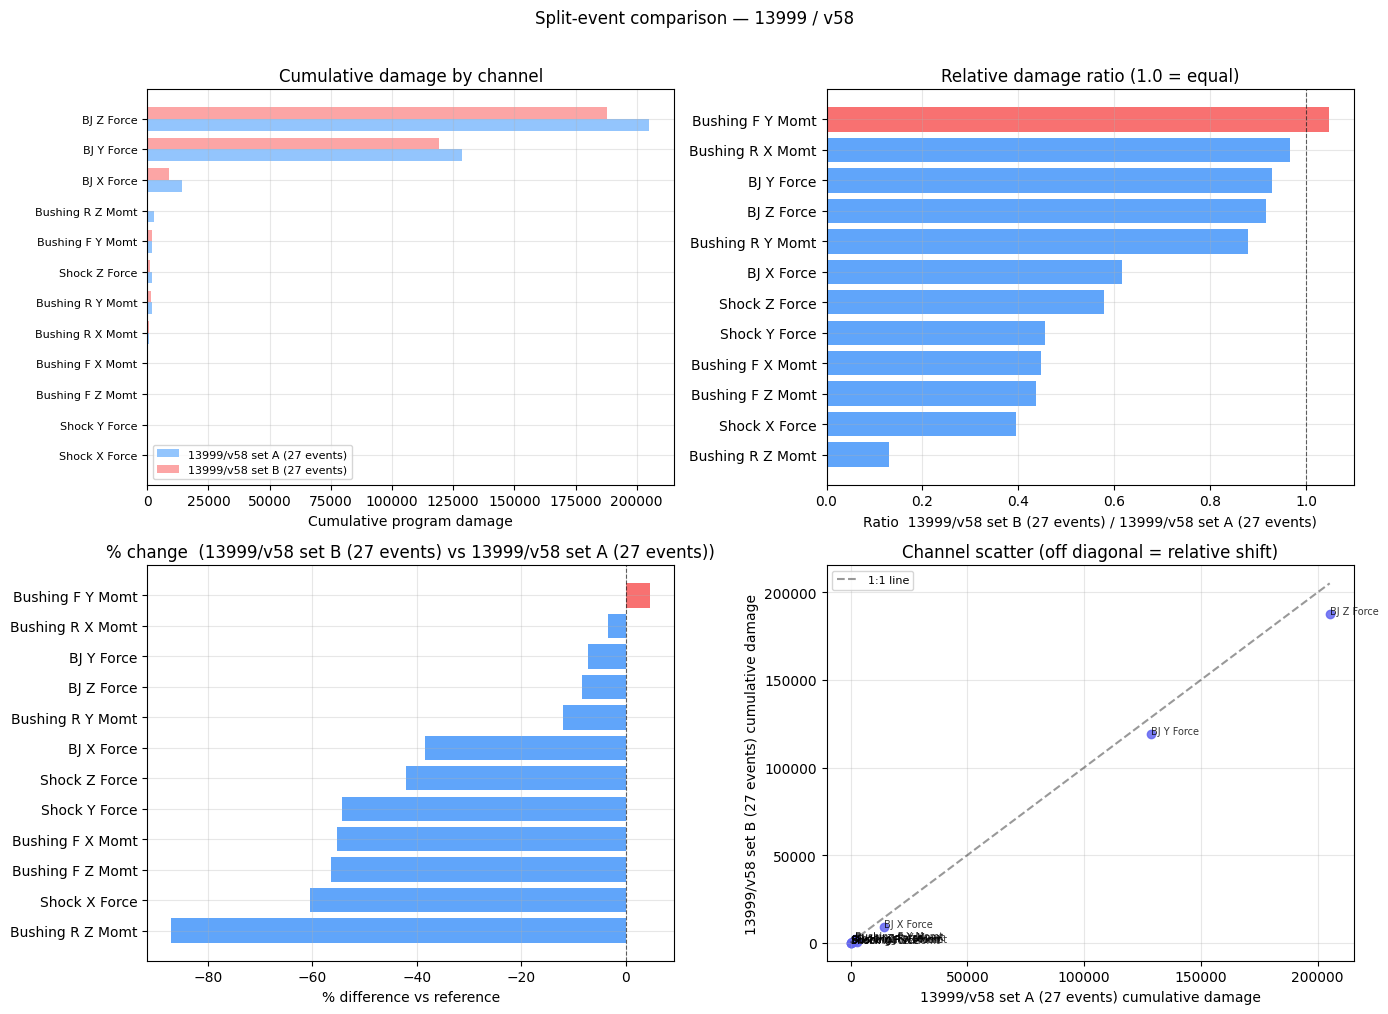

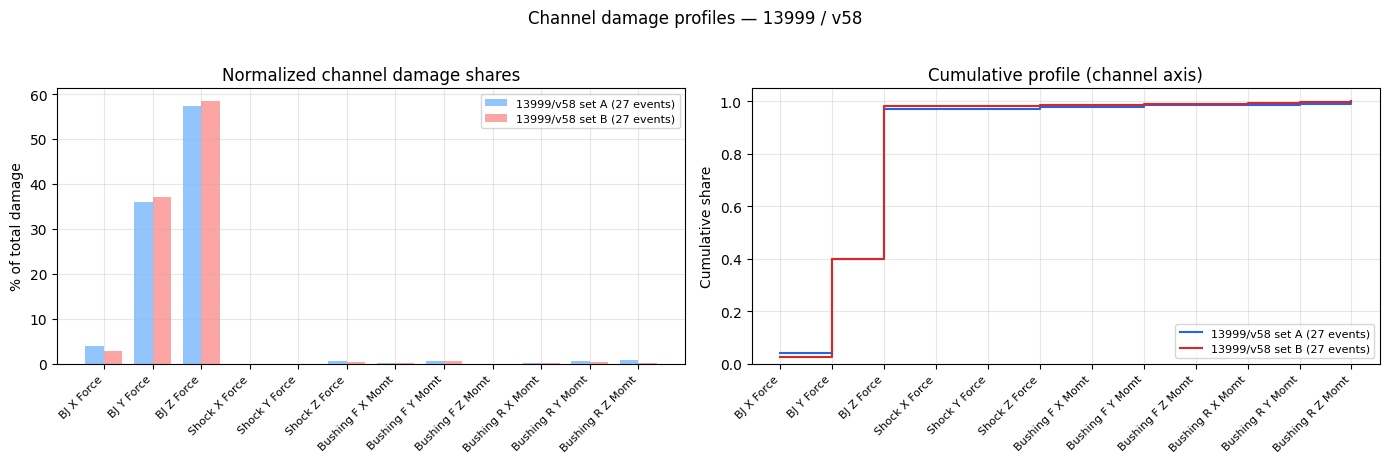

In [27]:
MIN_REFERENCE_DAMAGE = 1e-12


def split_events_into_equal_halves(
    events_df: pd.DataFrame,
    *,
    seed: int | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Randomly shuffle events, then split into two equal halves."""
    n = len(events_df)
    if n < 2:
        raise ValueError(f"Need at least 2 events to split, got {n}")

    shuffled = events_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    if n % 2:
        dropped = shuffled.iloc[-1]["matched_pattern"]
        print(f"Warning: {n} events is odd — dropping one event after shuffle ({dropped}) for equal halves")
        shuffled = shuffled.iloc[:-1]

    half = len(shuffled) // 2
    return shuffled.iloc[:half].copy(), shuffled.iloc[half:].copy()


def compare_cumulative_sets(
    cumulative_a: pd.DataFrame,
    cumulative_b: pd.DataFrame,
    label_a: str,
    label_b: str,
) -> pd.DataFrame:
    merged = cumulative_a.merge(
        cumulative_b,
        on=["channel_key", "channel_label"],
        how="outer",
        suffixes=("_a", "_b"),
    )
    ref = merged["cumulative_d_program_a"].replace(0, np.nan)
    merged["ratio_b_over_a"] = merged["cumulative_d_program_b"] / ref
    merged["pct_diff"] = 100.0 * (merged["cumulative_d_program_b"] - merged["cumulative_d_program_a"]) / ref

    ref_share = merged["pct_of_total_a"].replace(0, np.nan)
    merged["normalized_ratio_b_over_a"] = merged["pct_of_total_b"] / ref_share

    merged["low_reference_a"] = merged["cumulative_d_program_a"].fillna(0) < MIN_REFERENCE_DAMAGE
    merged["label_a"] = label_a
    merged["label_b"] = label_b
    return merged.sort_values("ratio_b_over_a", ascending=False, na_position="last")


DAMAGE_CHANNEL_AXIS_ORDER: tuple[str, ...] = tuple(DAMAGE_CHANNEL_LABELS.keys())


def channel_share_weights(
    cumulative_df: pd.DataFrame,
    channel_order: tuple[str, ...] = DAMAGE_CHANNEL_AXIS_ORDER,
) -> tuple[np.ndarray, np.ndarray, list[str]]:
    lookup = cumulative_df.set_index("channel_key")
    positions = np.arange(len(channel_order), dtype=float)
    weights = np.zeros(len(channel_order), dtype=float)
    labels: list[str] = []
    for i, key in enumerate(channel_order):
        labels.append(DAMAGE_CHANNEL_LABELS[key])
        if key in lookup.index:
            share = lookup.at[key, "pct_of_total"]
            weights[i] = float(share) if pd.notna(share) else 0.0
    total = weights.sum()
    if total > 0:
        weights /= total
    return positions, weights, labels


def plot_channel_profile_comparison(
    cumulative_a: pd.DataFrame,
    cumulative_b: pd.DataFrame,
    label_a: str,
    label_b: str,
    title: str,
) -> None:
    pos, weights_a, labels = channel_share_weights(cumulative_a)
    _, weights_b, _ = channel_share_weights(cumulative_b)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    x = np.arange(len(labels))
    width = 0.38

    ax = axes[0]
    ax.bar(x - width / 2, weights_a * 100.0, width=width, label=label_a, color="#93c5fd")
    ax.bar(x + width / 2, weights_b * 100.0, width=width, label=label_b, color="#fca5a5")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("% of total damage")
    ax.set_title("Normalized channel damage shares")
    ax.legend(fontsize=8)

    cdf_a = np.cumsum(weights_a)
    cdf_b = np.cumsum(weights_b)
    ax = axes[1]
    ax.step(pos, cdf_a, where="post", label=label_a, color="#2563eb")
    ax.step(pos, cdf_b, where="post", label=label_b, color="#dc2626")
    ax.set_xticks(pos)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Cumulative share")
    ax.set_ylim(0, 1.05)
    ax.set_title("Cumulative profile (channel axis)")
    ax.legend(fontsize=8)

    fig.suptitle(title, fontsize=12, y=1.02)
    fig.tight_layout()
    plt.show()


def plot_cumulative_comparison(
    compare_df: pd.DataFrame,
    label_a: str,
    label_b: str,
    title: str,
) -> None:
    plot_df = compare_df.sort_values("cumulative_d_program_a", ascending=True)
    labels = plot_df["channel_label"].tolist()
    x = np.arange(len(labels))
    width = 0.38

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Side-by-side cumulative damage
    ax = axes[0, 0]
    ax.barh(x - width / 2, plot_df["cumulative_d_program_a"], height=width, label=label_a, color="#93c5fd")
    ax.barh(x + width / 2, plot_df["cumulative_d_program_b"], height=width, label=label_b, color="#fca5a5")
    ax.set_yticks(x)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Cumulative program damage")
    ax.set_title("Cumulative damage by channel")
    ax.legend(fontsize=8)

    # Ratio B / A
    ax = axes[0, 1]
    ratio_df = plot_df.sort_values("ratio_b_over_a", ascending=True)
    colors = ["#f87171" if r > 1 else "#60a5fa" for r in ratio_df["ratio_b_over_a"].fillna(0)]
    ax.barh(ratio_df["channel_label"], ratio_df["ratio_b_over_a"], color=colors)
    ax.axvline(1.0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_xlabel(f"Ratio  {label_b} / {label_a}")
    ax.set_title("Relative damage ratio (1.0 = equal)")

    # % difference
    ax = axes[1, 0]
    pct_df = plot_df.sort_values("pct_diff", ascending=True)
    colors = ["#f87171" if p > 0 else "#60a5fa" for p in pct_df["pct_diff"].fillna(0)]
    ax.barh(pct_df["channel_label"], pct_df["pct_diff"], color=colors)
    ax.axvline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_xlabel("% difference vs reference")
    ax.set_title(f"% change  ({label_b} vs {label_a})")

    # Scatter A vs B
    ax = axes[1, 1]
    finite = plot_df.dropna(subset=["cumulative_d_program_a", "cumulative_d_program_b"])
    ax.scatter(finite["cumulative_d_program_a"], finite["cumulative_d_program_b"], c="#6366f1", alpha=0.85)
    max_val = max(finite["cumulative_d_program_a"].max(), finite["cumulative_d_program_b"].max())
    ax.plot([0, max_val], [0, max_val], "k--", alpha=0.4, label="1:1 line")
    for _, row in finite.iterrows():
        ax.annotate(row["channel_label"], (row["cumulative_d_program_a"], row["cumulative_d_program_b"]), fontsize=7, alpha=0.8)
    ax.set_xlabel(f"{label_a} cumulative damage")
    ax.set_ylabel(f"{label_b} cumulative damage")
    ax.set_title("Channel scatter (off diagonal = relative shift)")
    ax.legend(fontsize=8)

    fig.suptitle(title, fontsize=12, y=1.01)
    fig.tight_layout()
    plt.show()


events_set_a, events_set_b = split_events_into_equal_halves(events_df, seed=SPLIT_RANDOM_SEED)
label_a = f"{PROGRAM}/{VERSION} set A ({len(events_set_a)} events)"
label_b = f"{PROGRAM}/{VERSION} set B ({len(events_set_b)} events)"

print(f"Split random seed: {SPLIT_RANDOM_SEED}")
print("Set A patterns:", events_set_a["matched_pattern"].tolist())
print("Set B patterns:", events_set_b["matched_pattern"].tolist())

detail_a = compute_program_damage_detail(events_set_a, DATA_DIR, PROGRAM, VERSION)
detail_b = compute_program_damage_detail(events_set_b, DATA_DIR, PROGRAM, VERSION)
cumulative_a = compute_cumulative_by_channel(detail_a)
cumulative_b = compute_cumulative_by_channel(detail_b)

split_compare_df = compare_cumulative_sets(cumulative_a, cumulative_b, label_a, label_b)
display(split_compare_df.round(4))

if split_compare_df["low_reference_a"].any():
    flagged = split_compare_df.loc[split_compare_df["low_reference_a"], "channel_label"].tolist()
    print(f"Note: raw ratio/% diff unreliable for near-zero reference channels: {flagged}")

plot_cumulative_comparison(
    split_compare_df,
    label_a,
    label_b,
    f"Split-event comparison — {PROGRAM} / {VERSION}",
)

plot_channel_profile_comparison(
    cumulative_a,
    cumulative_b,
    label_a,
    label_b,
    f"Channel damage profiles — {PROGRAM} / {VERSION}",
)


## Step 12 — Inspect rainflow bins & Miner damage per bin

This mirrors the [py-fatigue damage tutorial](https://owi-lab.github.io/py_fatigue/user/examples/07-damage.html) workflow:

1. `cc.to_df()` — rainflow bins with `count_cycle`, `mean_stress`, `stress_range`
2. `df.miner.damage(sn_curve)` — adds `cycles_to_failure` and `pm_damage` per bin
3. `sum(pm_damage)` must equal `get_pm(cc, sn_curve)`

### Plot — per-bin Palmgren–Miner contribution (Step 9a)

The bar chart shows which stress ranges contribute most to \(D_{\text{single}} = \sum n_j/N_j\) before schedule scaling.

Sample: mfeb3_100_bt1cc_coil_2m14_lt27550r22_plus5_26jul24_lca_lr_app.csv / BJ Z Force
get_pm sum:     134.750154
df pm_damage:   134.750154
× schedule:    × 900.0 → d_program = 121275.138168


,count_cycle,mean_stress,stress_range,cycles_to_failure,pm_damage
0,1.0,11553.090100,0.906943,3.404871e+16,2.936969e-17
1,1.0,11553.997043,0.906943,3.404871e+16,2.936969e-17
2,1.0,11554.450514,1.813885,1.064022e+15,9.398300e-16
3,1.0,11553.997043,0.906943,3.404871e+16,2.936969e-17
4,1.0,11554.450514,1.813885,1.064022e+15,9.398300e-16
5,1.0,11555.810928,0.906943,3.404871e+16,2.936969e-17
6,0.5,11671.446128,237.618998,2.913108e+05,1.716380e-06
7,1.0,12550.727115,0.906943,3.404871e+16,2.936969e-17
8,1.0,12588.818710,2.720828,1.401181e+14,7.136834e-15
9,1.0,12591.086067,9.069427,3.404871e+11,2.936969e-12


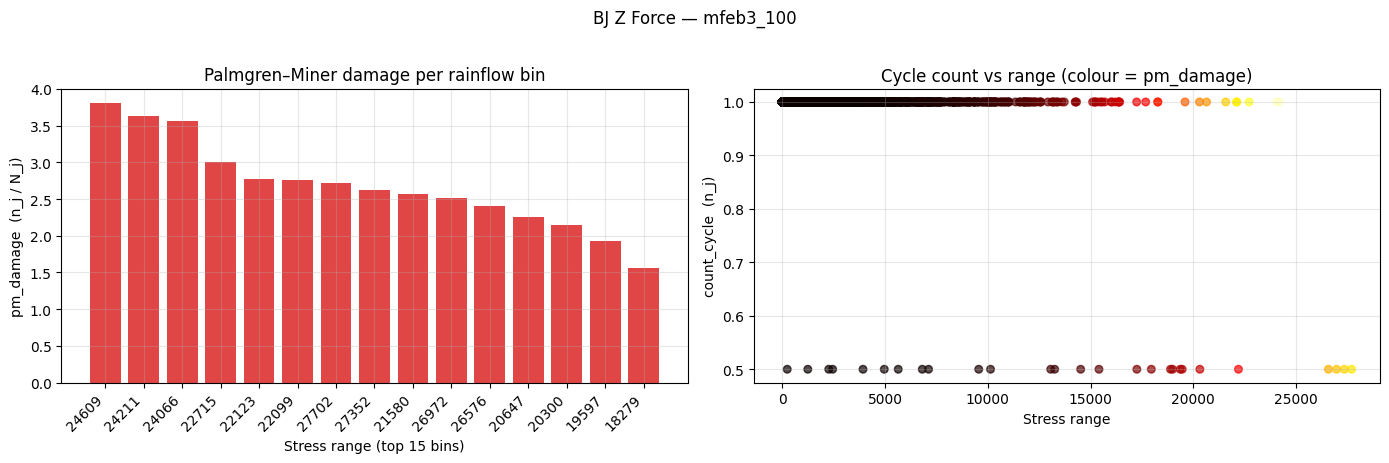

In [28]:
if detail_df.empty:
    print("No detail rows to inspect.")
else:
    sample = detail_df.dropna(subset=["d_single"]).sort_values("d_single", ascending=False).iloc[0]
    sample_df, _ = parse_tagged_csv(DATA_DIR / sample["rsp_file_name"])
    values = sample_df[sample["csv_column"]].to_numpy(dtype=float)
    finite = values[np.isfinite(values)]
    cc = pf.CycleCount.from_timeseries(
        finite,
        time=np.arange(finite.size, dtype=float),
        mean_bin_width=MEAN_BIN_WIDTH,
        range_bin_width=RANGE_BIN_WIDTH,
    )
    bins = cc.to_df()
    bins.miner.damage(SN_CURVE)
    d_single = float(bins["pm_damage"].sum())
    print(
        f"Sample: {sample['rsp_file_name']} / {sample['channel_label']}\n"
        f"get_pm sum:     {sum(pf.damage.stress_life.get_pm(cc, SN_CURVE)):.6f}\n"
        f"df pm_damage:   {d_single:.6f}\n"
        f"× schedule:    × {sample['schedule_scale']} → d_program = {sample['d_program']:.6f}"
    )
    display(bins[["count_cycle", "mean_stress", "stress_range", "cycles_to_failure", "pm_damage"]].head(10))

    # Top bins by pm_damage
    top_bins = bins.nlargest(15, "pm_damage")
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    axes[0].bar(
        range(len(top_bins)),
        top_bins["pm_damage"],
        color="#dc2626",
        alpha=0.85,
    )
    axes[0].set_xticks(range(len(top_bins)))
    axes[0].set_xticklabels(top_bins["stress_range"].round(0).astype(int), rotation=45, ha="right")
    axes[0].set_xlabel("Stress range (top 15 bins)")
    axes[0].set_ylabel("pm_damage  (n_j / N_j)")
    axes[0].set_title("Palmgren–Miner damage per rainflow bin")

    axes[1].scatter(
        bins["stress_range"],
        bins["count_cycle"],
        c=bins["pm_damage"],
        cmap="hot",
        s=30,
        alpha=0.7,
    )
    axes[1].set_xlabel("Stress range")
    axes[1].set_ylabel("count_cycle  (n_j)")
    axes[1].set_title("Cycle count vs range (colour = pm_damage)")
    fig.suptitle(f"{sample['channel_label']} — {sample['matched_pattern']}", y=1.02)
    fig.tight_layout()
    plt.show()

## Step 11 — Cross-program / cross-version relative damage

Compare **full** cumulative program damage between two program/version folders using the same per-channel absolute ratio, normalized ratio, and % difference from Step 10.

Set `COMPARE_PROGRAM_B` and `COMPARE_VERSION_B` in Step 0. When both folders are identical, this step reuses the Step 10 split-set comparison as a sanity check.


Reference and comparison folders are identical — reusing Step 10 split-set comparison
Reference:  13999/v58  (/data/home/tkodippili/Desktop/localTest_Analysis_DashboardV3/Dashboard/RAW_DATA/raw/13999/v58_data_processing)
Comparison: 13999/v58  (/data/home/tkodippili/Desktop/localTest_Analysis_DashboardV3/Dashboard/RAW_DATA/raw/13999/v58_data_processing)
Channels compared: 12



,channel_key,channel_label,cumulative_d_program_a,events_contributing_a,max_d_single_a,pct_of_total_a,cumulative_d_program_b,events_contributing_b,max_d_single_b,pct_of_total_b,ratio_b_over_a,pct_diff,normalized_ratio_b_over_a,low_reference_a,label_a,label_b
4,bushing_f_y_momt,Bushing F Y Momt,2023.9989,17,36.8634,0.5657,2118.4344,19,34.5889,0.6581,1.0467,4.6658,1.1632,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
6,bushing_r_x_momt,Bushing R X Momt,593.4792,17,15.0772,0.1659,573.5192,19,13.0325,0.1782,0.9664,-3.3632,1.0740,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
1,bj_y_force,BJ Y Force,128537.8362,27,80.6125,35.9290,119247.9858,27,88.1138,37.0451,0.9277,-7.2273,1.0311,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
2,bj_z_force,BJ Z Force,205123.7174,27,134.7502,57.3363,187811.5869,27,134.5334,58.3448,0.9156,-8.4398,1.0176,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
7,bushing_r_y_momt,Bushing R Y Momt,1800.5052,17,33.6928,0.5033,1582.0426,19,29.8700,0.4915,0.8787,-12.1334,0.9765,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
0,bj_x_force,BJ X Force,14355.4105,27,75.4576,4.0126,8846.4095,27,68.9685,2.7482,0.6162,-38.3758,0.6849,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
11,shock_z_force,Shock Z Force,1913.3961,17,5.6505,0.5348,1108.4852,19,42.0588,0.3444,0.5793,-42.0671,0.6439,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
10,shock_y_force,Shock Y Force,11.4241,17,0.0270,0.0032,5.2122,19,0.1643,0.0016,0.4562,-54.3754,0.5071,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
3,bushing_f_x_momt,Bushing F X Momt,428.2287,17,7.4123,0.1197,191.5865,19,7.3120,0.0595,0.4474,-55.2607,0.4972,False,13999/v58 set A (27 events),13999/v58 set B (27 events)
5,bushing_f_z_momt,Bushing F Z Momt,93.1008,17,0.2673,0.0260,40.5616,19,0.7721,0.0126,0.4357,-56.4326,0.4842,False,13999/v58 set A (27 events),13999/v58 set B (27 events)


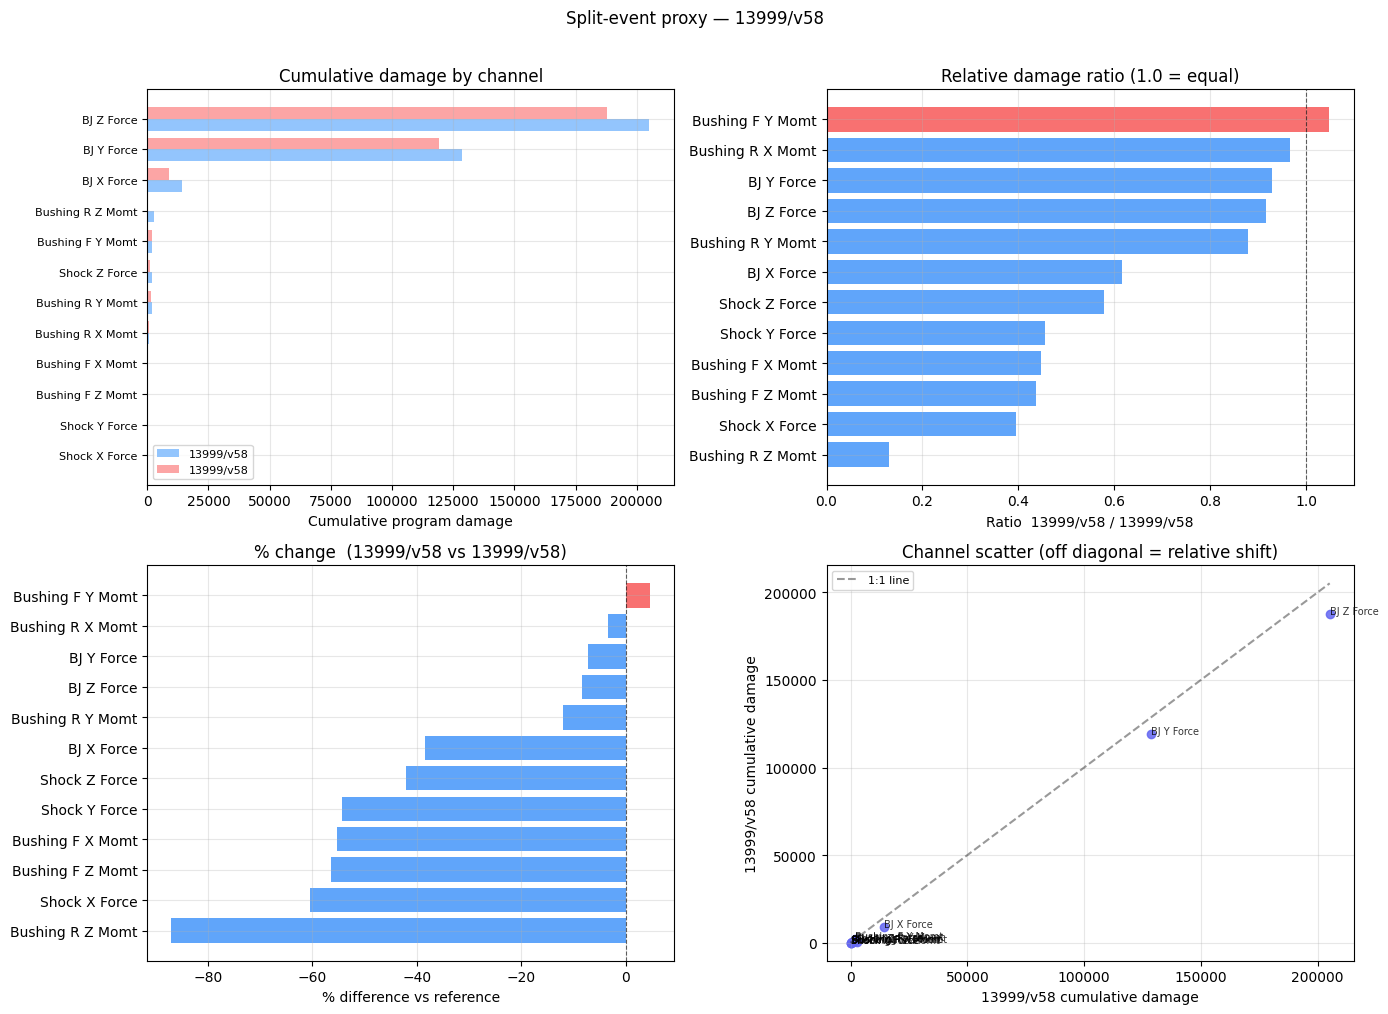

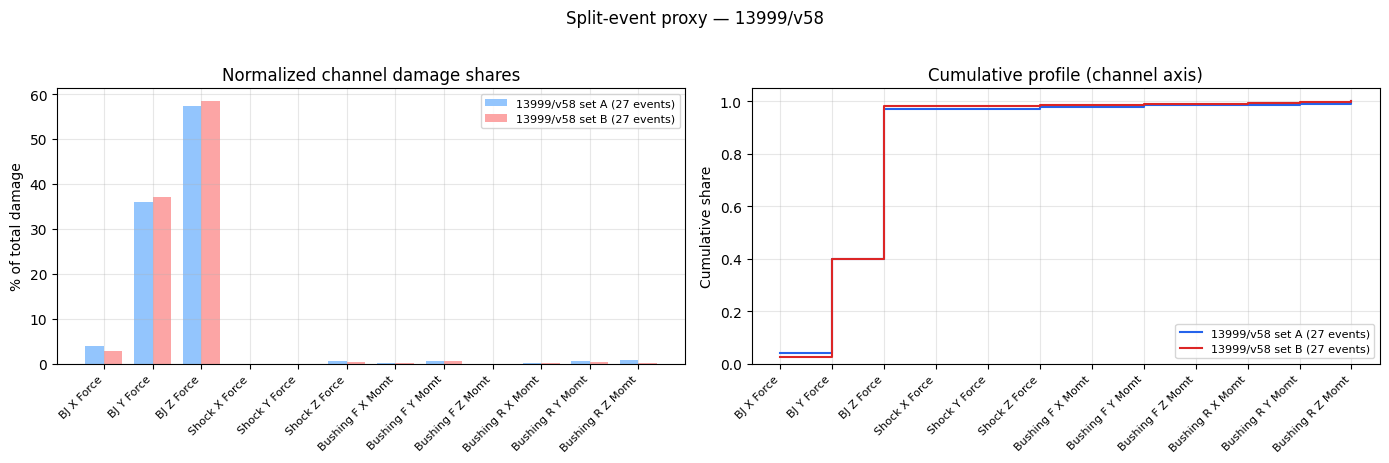

Top 5 channels by absolute ratio (comparison / reference):


,channel_label,cumulative_d_program_a,cumulative_d_program_b,ratio_b_over_a,normalized_ratio_b_over_a,pct_diff
4,Bushing F Y Momt,2023.9989,2118.4344,1.0467,1.1632,4.6658
6,Bushing R X Momt,593.4792,573.5192,0.9664,1.0740,-3.3632
1,BJ Y Force,128537.8362,119247.9858,0.9277,1.0311,-7.2273
2,BJ Z Force,205123.7174,187811.5869,0.9156,1.0176,-8.4398
7,Bushing R Y Momt,1800.5052,1582.0426,0.8787,0.9765,-12.1334


Top 5 channels by normalized ratio (share shift):


,channel_label,pct_of_total_a,pct_of_total_b,normalized_ratio_b_over_a
4,Bushing F Y Momt,0.5657,0.6581,1.1632
6,Bushing R X Momt,0.1659,0.1782,1.0740
1,BJ Y Force,35.9290,37.0451,1.0311
2,BJ Z Force,57.3363,58.3448,1.0176
7,Bushing R Y Momt,0.5033,0.4915,0.9765


In [29]:
def load_schedule_and_events(data_dir: Path) -> tuple[dict, pd.DataFrame]:
    sch_files = sorted(data_dir.glob("*.sch"))
    if not sch_files:
        raise FileNotFoundError(f"No .sch schedule in {data_dir}")
    schedule = parse_autodam_schedule(sch_files[0])
    schedule_df = pd.DataFrame(schedule["entries"])
    patterns = schedule_df["pattern"].tolist()
    lookup = schedule_df.reset_index().rename(columns={"index": "schedule_sequence"})
    lookup["schedule_sequence"] = lookup["schedule_sequence"] + 1

    event_rows: list[dict] = []
    for csv_path in sorted(data_dir.glob("*.csv")):
        stem = csv_path.stem
        matched = match_schedule_pattern(stem, patterns)
        row: dict = {"rsp_file_name": csv_path.name, "matched_pattern": matched}
        if matched:
            meta = lookup.loc[lookup["pattern"] == matched].iloc[0]
            row.update(
                {
                    "repeats": int(meta["repeats"]),
                    "weight": float(meta["weight"]),
                    "schedule_sequence": int(meta["schedule_sequence"]),
                }
            )
        event_rows.append(row)

    events = pd.DataFrame(event_rows)
    events["global_multiplier"] = schedule["multiplier"]
    events["schedule_scale"] = events["repeats"] * events["weight"] * events["global_multiplier"]
    return schedule, events


DATA_DIRS_B = {
    "test": REPO_ROOT / "RAW_DATA/test" / COMPARE_PROGRAM_B / COMPARE_VERSION_B,
    "raw": REPO_ROOT / "RAW_DATA/raw" / COMPARE_PROGRAM_B / f"{COMPARE_VERSION_B}_data_processing",
}
DATA_DIR_B = DATA_DIRS_B[DATA_SOURCE]

label_ref = f"{PROGRAM}/{VERSION}"
label_cmp = f"{COMPARE_PROGRAM_B}/{COMPARE_VERSION_B}"

same_folder = (PROGRAM, VERSION) == (COMPARE_PROGRAM_B, COMPARE_VERSION_B) and DATA_DIR.resolve() == DATA_DIR_B.resolve()

if same_folder:
    print("Reference and comparison folders are identical — reusing Step 10 split-set comparison")
    prog_compare_df = split_compare_df.copy()
    plot_title = f"Split-event proxy — {label_ref}"
else:
    if not DATA_DIR_B.is_dir():
        raise FileNotFoundError(f"Comparison data dir missing: {DATA_DIR_B}")
    _, events_b = load_schedule_and_events(DATA_DIR_B)
    detail_b_full = compute_program_damage_detail(events_b, DATA_DIR_B, COMPARE_PROGRAM_B, COMPARE_VERSION_B)
    cumulative_b_full = compute_cumulative_by_channel(detail_b_full)
    prog_compare_df = compare_cumulative_sets(cumulative_df, cumulative_b_full, label_ref, label_cmp)
    plot_title = f"Cross-program comparison — {label_ref} vs {label_cmp}"

print(f"Reference:  {label_ref}  ({DATA_DIR})")
print(f"Comparison: {label_cmp}  ({DATA_DIR_B})")
print(f"Channels compared: {len(prog_compare_df)}\n")

display(prog_compare_df.round(4))

plot_cumulative_comparison(prog_compare_df, label_ref, label_cmp, plot_title)

if same_folder:
    plot_channel_profile_comparison(cumulative_a, cumulative_b, label_a, label_b, plot_title)
else:
    plot_channel_profile_comparison(cumulative_df, cumulative_b_full, label_ref, label_cmp, plot_title)

# Summary — channels with largest relative shift
summary = prog_compare_df.loc[~prog_compare_df["low_reference_a"]].nlargest(5, "ratio_b_over_a")[
    ["channel_label", "cumulative_d_program_a", "cumulative_d_program_b", "ratio_b_over_a", "normalized_ratio_b_over_a", "pct_diff"]
]
print("Top 5 channels by absolute ratio (comparison / reference):")
display(summary.round(4))

norm_summary = prog_compare_df.loc[~prog_compare_df["low_reference_a"]].nlargest(5, "normalized_ratio_b_over_a")[
    ["channel_label", "pct_of_total_a", "pct_of_total_b", "normalized_ratio_b_over_a"]
]
print("Top 5 channels by normalized ratio (share shift):")
display(norm_summary.round(4))